In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE

# Step 2: Load Dataset
df = pd.read_csv("creditcard.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


0 missing values in dataset

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


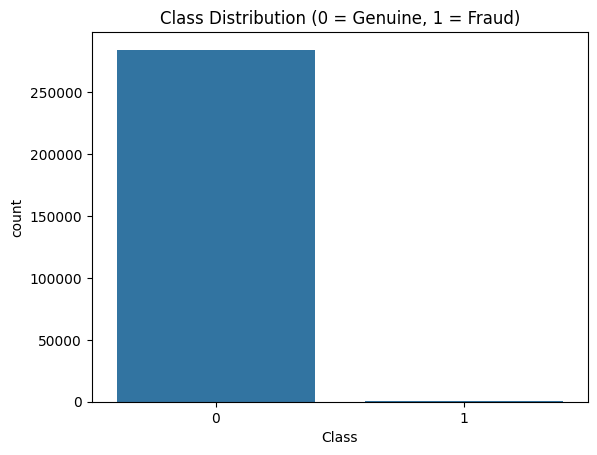

In [2]:
# Step 3: Check for missing values and class imbalance
print(df.isnull().sum().sum(), "missing values in dataset")

print("\nClass Distribution:")
print(df['Class'].value_counts())

sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0 = Genuine, 1 = Fraud)")
plt.show()


In [3]:
# Step 4: Split features and target
X = df.drop('Class', axis=1)
y = df['Class']


In [4]:
# Step 5: Standardize / Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [5]:
# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts())


Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64



After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


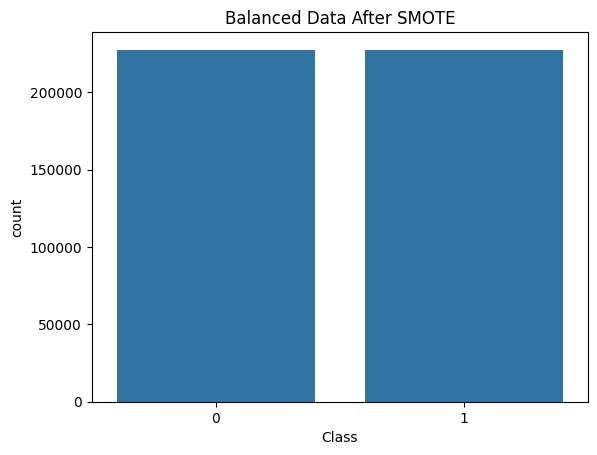

In [6]:
# Step 7: Handle Imbalance using SMOTE (apply only on training data)
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_res).value_counts())

sns.countplot(x=y_res)
plt.title("Balanced Data After SMOTE")
plt.show()


In [7]:
# Step 8: Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_res, y_res)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


✅ Model Evaluation:

Accuracy: 0.9994908886626171

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.83      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962



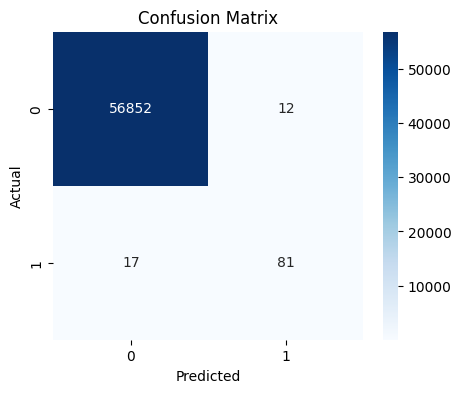

In [8]:
# Step 9: Evaluate the Model
y_pred = model.predict(X_test)

print("✅ Model Evaluation:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


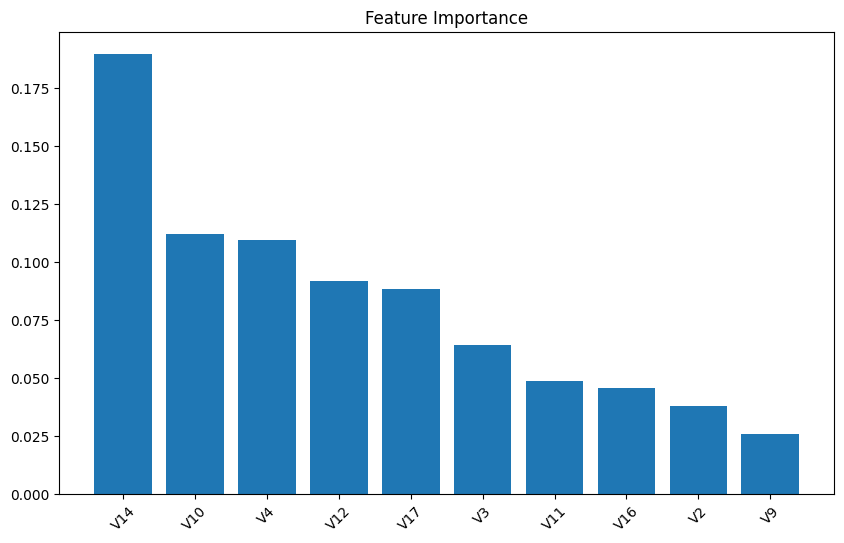

In [9]:
# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.bar(range(10), importances[indices][:10], align='center')
plt.xticks(range(10), np.array(df.columns[:-1])[indices][:10], rotation=45)
plt.show()


In [10]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved clean model.pkl and scaler.pkl successfully!")


Saved clean model.pkl and scaler.pkl successfully!
